<a href="https://colab.research.google.com/github/CarlosGer7/MetodosNum/blob/main/Punto%20Fijo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Método del Punto Fijo
**Estudiante:** [Leon Espinoza Carlos Germain]
**Ejemplo 1 (Pág. 38):** $f(x) = x^3 + 4x^2 - 10 = 0$

### Planteamiento
Se busca resolver la ecuación $x^3 + 4x^2 - 10 = 0$ en el intervalo $[1, 2]$ usando el método de punto fijo.
Para ello, transformamos la ecuación en la forma $x = g(x)$. Según el libro de Burden, existen múltiples formas de despejar $x$. Evaluaremos las 5 funciones propuestas con un valor inicial de $p_0 = 1.5$ y una tolerancia de $10^{-4}$.

Las funciones son:
(a) $g_1(x) = x - x^3 - 4x^2 + 10$

(b) $g_2(x) = \left(\frac{10}{x} - 4x\right)^{1/2}$

(c) $g_3(x) = \frac{1}{2}\left(10 - x^3\right)^{1/2}$

(d) $g_4(x) = \left(\frac{10}{4+x}\right)^{1/2}$

(e) $g_5(x) = x - \frac{x^3 + 4x^2 - 10}{3x^2 + 8x}$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definimos las 5 funciones de punto fijo g(x)

In [7]:
def g1(x): return x - x**3 - 4*x**2 + 10
def g2(x): return np.sqrt(10/x - 4*x) if (10/x - 4*x) >= 0 else np.nan
def g3(x): return 0.5 * np.sqrt(10 - x**3) if (10 - x**3) >= 0 else np.nan
def g4(x): return np.sqrt(10 / (4 + x))
def g5(x): return x - (x**3 + 4*x**2 - 10) / (3*x**2 + 8*x)

# Agrupamos en una lista para iterar

In [8]:
funciones_g = {
    '(a) g1': g1,
    '(b) g2': g2,
    '(c) g3': g3,
    '(d) g4': g4,
    '(e) g5': g5
}


In [10]:
def punto_fijo(g, p0, tol, n_max):

    resultados = []
    i = 1
    p_actual = p0

    while i <= n_max:

        # Paso 3: Calcular p = g(p0)

        try:
            p = g(p_actual)
        except Exception as e:

            # Si hay error (ej. raíz de negativo), detenemos
            resultados.append({'n': i, 'p_n': np.nan, 'Error': np.nan})
            break

        error = abs(p - p_actual)

        # Guardar datos
        resultados.append({
            'n': i,
            'p_n': p,
            'Error': error
        })

        # Paso 4: Criterio de parada
        if error < tol:
            break

        # Paso 5 y 6: Actualizar
        i += 1
        p_actual = p

    return pd.DataFrame(resultados)

print("Algoritmo de Punto Fijo definido.")

Algoritmo de Punto Fijo definido.


In [13]:
p0 = 1.5
tol = 1e-4
n_max = 30

# Diccionario para guardar la tabla
tablas = {}

# Ejecutamos para cada función
for nombre, func in funciones_g.items():
    df = punto_fijo(func, p0, tol, n_max)
    tablas[nombre] = df

# Crear una tabla comparativa
df_comparativa = pd.DataFrame()
df_comparativa['n'] = range(1, n_max + 1)

for nombre, df in tablas.items():
    valores = df['p_n'].tolist()
    valores += [np.nan] * (n_max - len(valores))
    df_comparativa[nombre] = valores

# Mostramos la tabla
print("Tabla Comparativa de Convergencia: ")
display(df_comparativa.head(15))

Tabla Comparativa de Convergencia: 


/usr/local/lib/python3.13/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,n,(a) g1,(b) g2,(c) g3,(d) g4,(e) g5
0,1,-8.750000e-01,0.816497,1.286954,1.348400,1.373333
1,2,6.732422e+00,2.996909,1.402541,1.367376,1.365262
2,3,-4.697200e+02,NaN,1.345458,1.364957,1.365230
3,4,1.027546e+08,NaN,1.375170,1.365265,NaN
4,5,-1.084934e+24,NaN,1.360094,1.365226,NaN
5,6,1.277056e+72,NaN,1.367847,NaN,NaN
6,7,-2.082713e+216,NaN,1.363887,NaN,NaN
7,8,NaN,NaN,1.365917,NaN,NaN
8,9,NaN,NaN,1.364878,NaN,NaN
9,10,NaN,NaN,1.365410,NaN,NaN


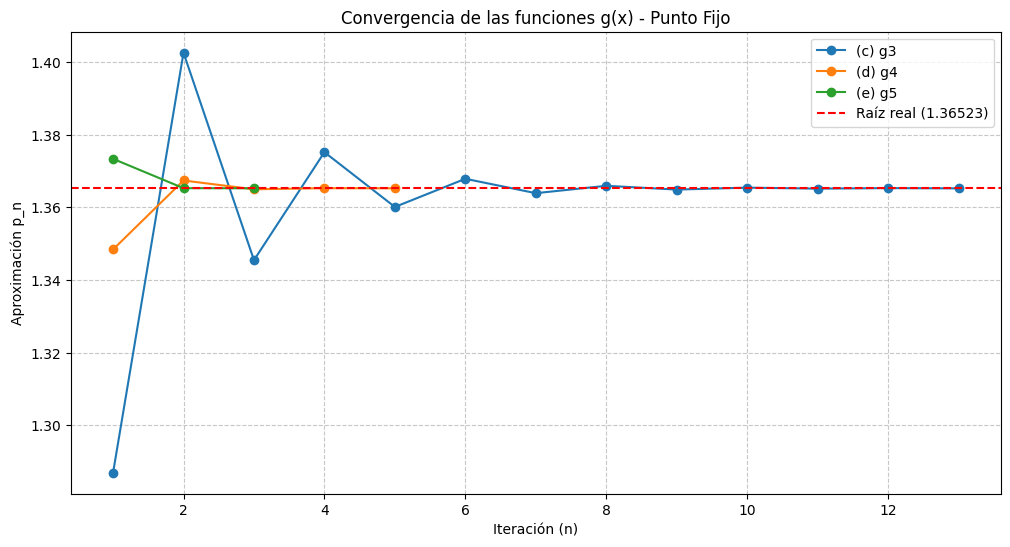

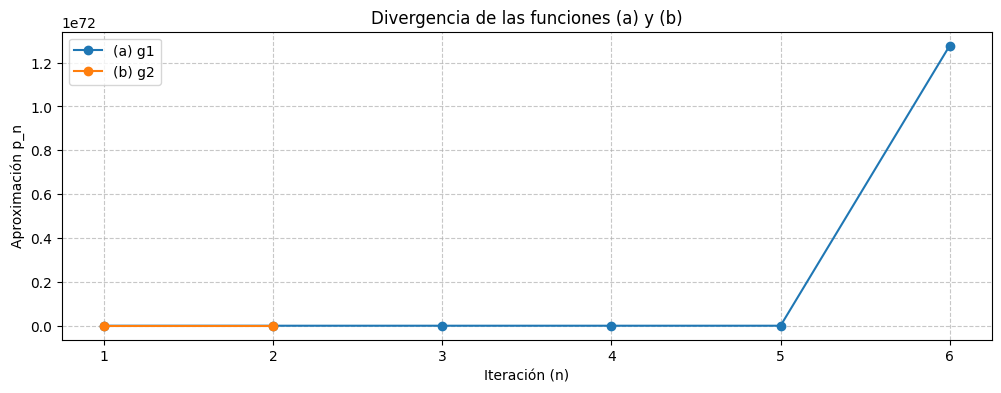

In [6]:
# Generar gráfica para visualizar el comportamiento
plt.figure(figsize=(12, 6))

# Graficamos solo las funciones que convergen
for nombre in ['(c) g3', '(d) g4', '(e) g5']:
    df = tablas[nombre]
    plt.plot(df['n'], df['p_n'], marker='o', label=nombre)

plt.axhline(1.365230013, color='red', linestyle='--', label='Raíz real (1.36523)')
plt.title('Convergencia de las funciones g(x) - Punto Fijo')
plt.xlabel('Iteración (n)')
plt.ylabel('Aproximación p_n')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Gráfica aparte para las funciones que divergen
plt.figure(figsize=(12, 4))
for nombre in ['(a) g1', '(b) g2']:
    df = tablas[nombre].head(6)
    plt.plot(df['n'], df['p_n'], marker='o', label=nombre)

plt.title('Divergencia de las funciones (a) y (b)')
plt.xlabel('Iteración (n)')
plt.ylabel('Aproximación p_n')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

1. **Convergencia:** El método de punto fijo no siempre converge. La convergencia depende de la derivada de $g(x)$. Si $|g'(x)| < 1$ en el intervalo, el método converge. Si $|g'(x)| > 1$, diverge.

2. **Análisis de las funciones:**
   * **(a) y (b):** Divergen rápidamente porque sus derivadas son mayores a 1 en el intervalo (y en (b) ocurre una raíz cuadrada de un número negativo).
   * **(c):** Converge, pero de forma muy lenta (como se ve en la tabla, tarda más de 15 iteraciones). Su derivada es cercana a 1.
   * **(d) y (e):** Convergen muy rápido. La función (d) es una transformación algebraica eficiente. La función (e) es en realidad el **Método de Newton-Raphson**, el cual tiene convergencia cuadrática (duplica los dígitos de precisión en cada paso).
   
3. **Resultado Final:** La raíz real es $x \approx 1.365230013$. Los métodos (d) y (e) alcanzaron este valor en pocas iteraciones, demostrando que la elección de la función $g(x)$ es crucial para la eficiencia del método.
